# Учебный проект по статистике: A/B-тест и анализ данных маркетплейса

## 1. Описание проекта

Проект выполнен как учебная работа в рамках модуля «Статистика» курса по аналитике данных.

Цель проекта — применить статистические методы к данным маркетплейса и проверить несколько бизнес-гипотез: повлиял ли новый дашборд на время обработки заказов, изменилась ли активность клиентов после введения бесплатной доставки, а также связаны ли между собой тип продаваемых товаров и стаж продавцов.

В работе используются методы описательной статистики, проверки статистических гипотез, t-тесты для независимых и парных выборок, критерий хи-квадрат для таблиц сопряжённости и доверительные интервалы. 

## 2. Загрузка библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

## 3. Задание 1. A/B-тест: влияние дашборда на время обработки заказов

В этом задании проверяется, помог ли новый интерактивный дашборд продавцам быстрее обрабатывать заказы. Для этого сравниваются две независимые группы: контрольная группа работала со старым интерфейсом, а тестовая группа — с новым дашбордом.

In [2]:
# Загружаем данные по контрольной и тестовой группам для задания 1

control = pd.read_csv("../data/time_order_processing_control.csv")  # продавцы со старым интерфейсом
test = pd.read_csv("../data/time_order_processing_test.csv")        # продавцы с новым интерактивным дашбордом

control = control.drop(columns=["Unnamed: 0"])  # удаляем технический столбец со старым индексом
test = test.drop(columns=["Unnamed: 0"])        # удаляем технический столбец со старым индексом

control.head(), test.head()  # смотрим первые строки обеих таблиц

(    time
 0  29.68
 1  45.80
 2  26.00
 3  28.60
 4  24.48,
     time
 0  16.56
 1  23.76
 2  12.12
 3  13.80
 4  15.08)

In [3]:
# Проверяем размер выборок и наличие пропущенных значений

print("Размер контрольной группы:", control.shape)  # количество строк и столбцов в контрольной группе
print("Размер тестовой группы:", test.shape)        # количество строк и столбцов в тестовой группе

print("\nПропуски в контрольной группе:")
print(control.isna().sum())  # считаем пропуски по каждому столбцу

print("\nПропуски в тестовой группе:")
print(test.isna().sum())     # считаем пропуски по каждому столбцу

Размер контрольной группы: (1393, 1)
Размер тестовой группы: (1393, 1)

Пропуски в контрольной группе:
time    0
dtype: int64

Пропуски в тестовой группе:
time    0
dtype: int64


In [4]:
# Смотрим базовые статистики времени обработки заказов в двух группах

print("Контрольная группа:")
print(control["time"].describe())  # описательные статистики для старого интерфейса

print("\nТестовая группа:")
print(test["time"].describe())     # описательные статистики для нового дашборда

Контрольная группа:
count    1393.000000
mean       29.502828
std         8.979888
min         8.320000
25%        23.040000
50%        28.840000
75%        35.200000
max        67.160000
Name: time, dtype: float64

Тестовая группа:
count    1393.000000
mean       18.009160
std         5.857845
min         8.000000
25%        13.840000
50%        17.480000
75%        21.520000
max        44.520000
Name: time, dtype: float64


По первичному описанию данных видно, что время обработки заказов в тестовой группе ниже, чем в контрольной. Среднее время обработки заказа в контрольной группе составляет около 29.5 часа, а в тестовой группе — около 18.0 часа.

Однако одного сравнения средних недостаточно для статистического вывода. Далее нужно проверить гипотезу с помощью статистического теста для независимых выборок.

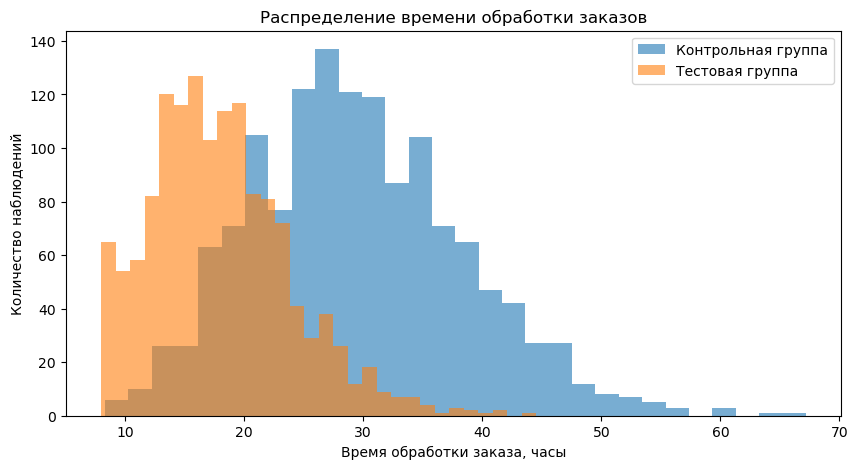

In [5]:
# Сравниваем распределения времени обработки заказов в контрольной и тестовой группах

plt.figure(figsize=(10, 5))

plt.hist(control["time"], bins=30, alpha=0.6, label="Контрольная группа")  # старый интерфейс
plt.hist(test["time"], bins=30, alpha=0.6, label="Тестовая группа")        # новый дашборд

plt.title("Распределение времени обработки заказов")
plt.xlabel("Время обработки заказа, часы")
plt.ylabel("Количество наблюдений")
plt.legend()

plt.show()

На графике видно, что распределение времени обработки заказов в тестовой группе смещено левее относительно контрольной группы. Это означает, что после внедрения интерактивного дашборда заказы чаще обрабатывались быстрее.

Для формальной проверки этого вывода используем статистический тест.

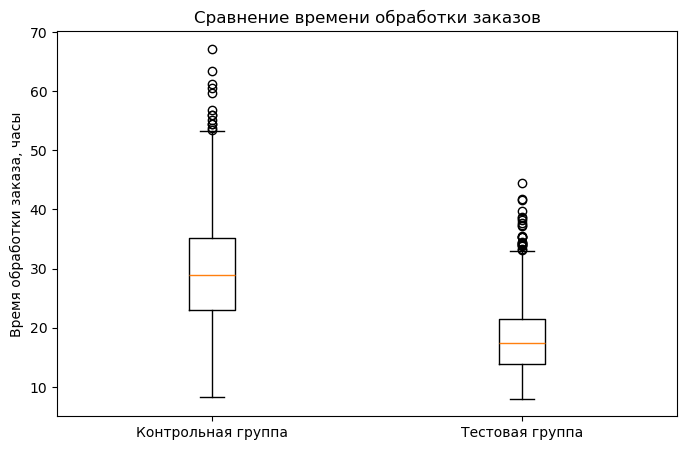

In [6]:
# Строим boxplot, чтобы проверить разброс значений и возможные выбросы

plt.figure(figsize=(8, 5))

plt.boxplot(
    [control["time"], test["time"]],
    tick_labels=["Контрольная группа", "Тестовая группа"]
)

plt.title("Сравнение времени обработки заказов")
plt.ylabel("Время обработки заказа, часы")

plt.show()

Boxplot показывает, что медианное время обработки заказов в тестовой группе ниже, чем в контрольной. Также видно, что в обеих группах есть отдельные высокие значения времени обработки заказа, но в контрольной группе они выше и разброс в целом больше.

Эти значения не удаляются, так как они могут быть частью естественного разброса данных. Для окончательного вывода используем статистический тест.

Формулируем гипотезы:

- H₀: среднее время обработки заказов в контрольной группе равно среднему времени обработки заказов в тестовой группе.
- H₁: среднее время обработки заказов в тестовой группе меньше, чем в контрольной группе.

Так как сравниваются две независимые выборки, для проверки используем t-тест для независимых выборок.

In [7]:
# Проверяем гипотезу с помощью t-теста для независимых выборок

alpha = 0.05  # уровень статистической значимости

t_stat, p_value = stats.ttest_ind(
    test["time"],       # тестовая группа: продавцы с новым дашбордом
    control["time"],    # контрольная группа: продавцы со старым интерфейсом
    alternative="less"  # альтернативная гипотеза: среднее время в тестовой группе меньше
)

print("t-статистика:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Отвергаем H0: время обработки заказов в тестовой группе статистически значимо меньше.")
else:
    print("Не отвергаем H0: статистически значимого уменьшения времени обработки заказов не обнаружено.")

t-статистика: -40.01055525962125
p-value: 2.9949647128013707e-277
Отвергаем H0: время обработки заказов в тестовой группе статистически значимо меньше.


Результат t-теста показал p-value значительно меньше уровня значимости 0.05. Поэтому нулевая гипотеза о равенстве среднего времени обработки заказов в контрольной и тестовой группах отвергается.

На основе данных можно сделать вывод, что использование интерактивного дашборда статистически значимо уменьшило среднее время обработки заказов продавцами.

Практический вывод: по данным A/B-теста новый интерактивный дашборд можно считать эффективным по выбранной метрике. Среднее время обработки заказов в тестовой группе ниже, поэтому решение можно рассматривать как успешное для ускорения работы продавцов.

## 4. Задание 2. Парная выборка: влияние бесплатной доставки на количество заказов

В этом задании проверяется, изменилось ли количество заказов у часто заказывающих клиентов после введения бесплатной доставки с шестого заказа. Для анализа сравниваются показатели одних и тех же клиентов в апреле и мае.

In [8]:
# Загружаем данные о количестве заказов клиентов в апреле и мае

orders = pd.read_csv("../data/clients_orders.csv")  # данные по одним и тем же клиентам до и после введения бесплатной доставки

orders = orders.drop(columns=["Unnamed: 0"])        # удаляем технический столбец со старым индексом

orders.head()                                       # смотрим первые строки таблицы

,orders_april,orders_may
0,1,13
1,5,7
2,10,8
3,11,6
4,1,10


In [9]:
# Проверяем размер данных и наличие пропущенных значений

print("Размер таблицы:", orders.shape)  # количество клиентов и столбцов в таблице

print("\nПропуски по столбцам:")
print(orders.isna().sum())              # считаем пропуски отдельно для апреля и мая

print("\nОписательная статистика:")
print(orders.describe())                # смотрим базовые статистики по количеству заказов

Размер таблицы: (1000, 2)

Пропуски по столбцам:
orders_april    0
orders_may      0
dtype: int64

Описательная статистика:
       orders_april   orders_may
count   1000.000000  1000.000000
mean       5.762000     7.982000
std        3.006392     2.414437
min        0.000000     2.000000
25%        3.000000     6.000000
50%        6.000000     8.000000
75%        8.000000    10.000000
max       14.000000    14.000000


In [10]:
# Считаем изменение количества заказов для каждого клиента

orders["orders_diff"] = orders["orders_may"] - orders["orders_april"]  # разница между маем и апрелем

orders.head()  # проверяем, что новый столбец добавился

,orders_april,orders_may,orders_diff
0,1,13,12
1,5,7,2
2,10,8,-2
3,11,6,-5
4,1,10,9


count    1000.000000
mean        2.220000
std         3.863227
min       -10.000000
25%        -1.000000
50%         2.000000
75%         5.000000
max        12.000000
Name: orders_diff, dtype: float64


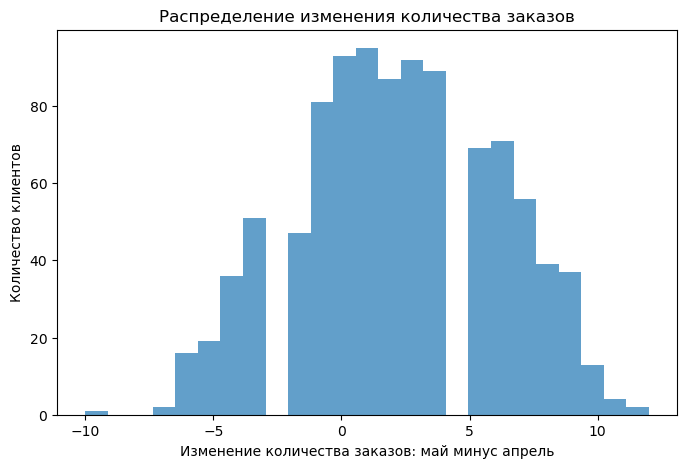

In [11]:
# Смотрим распределение изменений количества заказов

print(orders["orders_diff"].describe())  # описательные статистики по изменению заказов

plt.figure(figsize=(8, 5))

plt.hist(orders["orders_diff"], bins=25, alpha=0.7)  # распределение разницы между маем и апрелем

plt.title("Распределение изменения количества заказов")
plt.xlabel("Изменение количества заказов: май минус апрель")
plt.ylabel("Количество клиентов")

plt.show()

По описательной статистике видно, что в мае клиенты в среднем сделали больше заказов, чем в апреле. Среднее изменение составляет около 2.22 заказа на клиента, медианное изменение — 2 заказа.

Так как сравниваются показатели одних и тех же клиентов до и после введения бесплатной доставки, далее используем статистический тест для парных выборок.

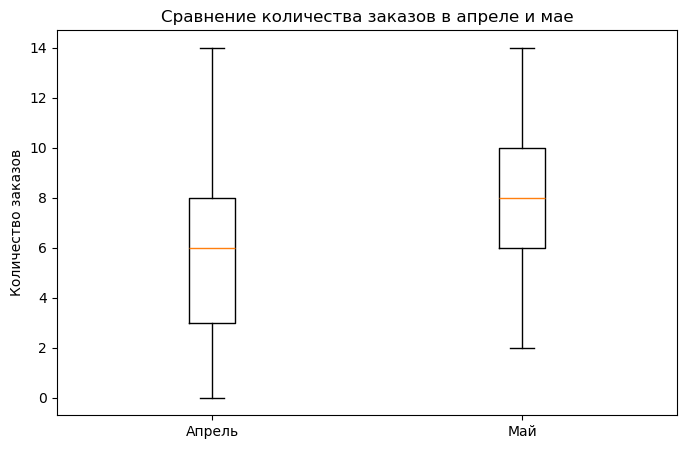

In [12]:
# Строим boxplot, чтобы сравнить количество заказов в апреле и мае

plt.figure(figsize=(8, 5))

plt.boxplot(
    [orders["orders_april"], orders["orders_may"]],
    tick_labels=["Апрель", "Май"]  # подписи месяцев на оси X
)

plt.title("Сравнение количества заказов в апреле и мае")
plt.ylabel("Количество заказов")

plt.show()

Boxplot показывает, что распределение количества заказов в мае смещено выше по сравнению с апрелем. Медианное количество заказов также выше в мае.

Формулируем гипотезы:

- H₀: среднее количество заказов клиентов в мае равно среднему количеству заказов в апреле.
- H₁: среднее количество заказов клиентов в мае больше, чем в апреле.

Так как сравниваются показатели одних и тех же клиентов за два месяца, выборки являются зависимыми. Для проверки используем t-тест для парных выборок.

In [13]:
# Проверяем гипотезу с помощью t-теста для парных выборок

alpha = 0.05  # уровень статистической значимости

t_stat, p_value = stats.ttest_rel(
    orders["orders_may"],      # количество заказов после введения бесплатной доставки
    orders["orders_april"],    # количество заказов до введения бесплатной доставки
    alternative="greater"      # альтернативная гипотеза: в мае заказов стало больше
)

print("t-статистика:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Отвергаем H0: количество заказов в мае статистически значимо больше, чем в апреле.")
else:
    print("Не отвергаем H0: статистически значимого увеличения количества заказов не обнаружено.")

t-статистика: 18.171999762294778
p-value: 2.8066025158955254e-64
Отвергаем H0: количество заказов в мае статистически значимо больше, чем в апреле.


Результат парного t-теста показал p-value значительно меньше уровня значимости 0.05. Поэтому нулевая гипотеза о равенстве среднего количества заказов в апреле и мае отвергается.

На основе данных можно сделать вывод, что после введения бесплатной доставки клиенты стали делать статистически значимо больше заказов.

Практический вывод: бесплатная доставка с шестого заказа могла положительно повлиять на активность часто заказывающих клиентов. После введения акции среднее количество заказов на клиента выросло, поэтому такую механику можно рассматривать как эффективный инструмент стимулирования повторных заказов.

## 5. Задание 3. Хи-квадрат: связь типа товара и стажа продавца

В этом задании проверяется, связан ли стаж продаж на маркетплейсе с типом продаваемых товаров. Оба признака являются категориальными, поэтому для проверки используется таблица сопряжённости и критерий хи-квадрат.

In [14]:
# Загружаем данные о продавцах маркетплейса

vendors = pd.read_csv("../data/vendors.csv")  # данные о типе товаров и стаже продавцов

vendors = vendors.drop(columns=["Unnamed: 0"])  # удаляем технический столбец со старым индексом

vendors.head()  # смотрим первые строки таблицы

,goods,experience
0,beauty,5-
1,beauty,3-5
2,outdoor,0-1
3,outdoor,0-1
4,clothes,3-5


In [15]:
# Проверяем размер таблицы, пропуски и значения категориальных переменных

print("Размер таблицы:", vendors.shape)  # количество продавцов и столбцов в таблице

print("\nПропуски по столбцам:")
print(vendors.isna().sum())              # проверяем пропуски в типе товара и стаже

print("\nТипы товаров:")
print(vendors["goods"].value_counts())   # считаем количество продавцов по типам товаров

print("\nСтаж продавцов:")
print(vendors["experience"].value_counts())  # считаем количество продавцов по группам стажа

Размер таблицы: (839, 2)

Пропуски по столбцам:
goods         0
experience    0
dtype: int64

Типы товаров:
goods
clothes        321
electronics    195
beauty         153
outdoor        131
pets            39
Name: count, dtype: int64

Стаж продавцов:
experience
1-3    324
0-1    261
5-     134
3-5    120
Name: count, dtype: int64


In [16]:
# Строим таблицу сопряжённости для типа товара и стажа продавца

vendors_table = pd.crosstab(
    vendors["experience"],  # строки: группы стажа продавцов
    vendors["goods"]        # столбцы: типы товаров
)

vendors_table  # смотрим распределение продавцов по двум категориальным признакам

goods,beauty,clothes,electronics,outdoor,pets
experience,,,,,
0-1,40,104,68,36,13
1-3,65,129,67,46,17
3-5,22,42,29,23,4
5-,26,46,31,26,5


Таблица сопряжённости показывает, сколько продавцов с разным стажем относится к каждому типу товаров. По этой таблице можно проверить, связаны ли два категориальных признака: тип товара и стаж продавца.

Формулируем гипотезы:

- H₀: стаж продаж на маркетплейсе не зависит от типа продаваемых товаров.
- H₁: стаж продаж на маркетплейсе зависит от типа продаваемых товаров.

Так как обе переменные являются категориальными, для проверки используем критерий хи-квадрат для таблицы сопряжённости.

In [17]:
# Проверяем гипотезу с помощью критерия хи-квадрат для таблицы сопряжённости

alpha = 0.05  # уровень статистической значимости

chi2_stat, p_value, dof, expected = stats.chi2_contingency(vendors_table)

print("Хи-квадрат статистика:", chi2_stat)
print("p-value:", p_value)
print("Степени свободы:", dof)

if p_value < alpha:
    print("Отвергаем H0: стаж продаж зависит от типа продаваемых товаров.")
else:
    print("Не отвергаем H0: статистически значимой связи между стажем продаж и типом товаров не обнаружено.")

Хи-квадрат статистика: 9.177972185008636
p-value: 0.687658762327187
Степени свободы: 12
Не отвергаем H0: статистически значимой связи между стажем продаж и типом товаров не обнаружено.


Результат критерия хи-квадрат показал p-value больше уровня значимости 0.05. Поэтому нулевая гипотеза о независимости стажа продаж и типа продаваемых товаров не отвергается.

На основе данных не обнаружено статистически значимой связи между типом товара и стажем продавца на маркетплейсе.

Практический вывод: по имеющимся данным нельзя утверждать, что продавцы с разным стажем чаще специализируются на определённых типах товаров. Для маркетплейса это означает, что тип продаваемых товаров не показывает статистически значимой связи со стажем продавца.

## 6. Задание 4. Доверительные интервалы

В этом задании строятся 90%-е доверительные интервалы для среднего времени обработки заказа в контрольной и тестовой группах.

Доверительный интервал показывает диапазон значений, в котором с заданным уровнем доверия может находиться истинное среднее значение в генеральной совокупности.

In [18]:
# Строим 90%-е доверительные интервалы для среднего времени обработки заказа

confidence = 0.90  # уровень доверия для интервала

control_ci = stats.t.interval(
    confidence=confidence,
    df=len(control["time"]) - 1,
    loc=control["time"].mean(),
    scale=stats.sem(control["time"])
)

test_ci = stats.t.interval(
    confidence=confidence,
    df=len(test["time"]) - 1,
    loc=test["time"].mean(),
    scale=stats.sem(test["time"])
)

print("90%-й доверительный интервал для контрольной группы:", control_ci)
print("90%-й доверительный интервал для тестовой группы:", test_ci)

90%-й доверительный интервал для контрольной группы: (np.float64(29.106813344586804), np.float64(29.898843511120305))
90%-й доверительный интервал для тестовой группы: (np.float64(17.750827806001592), np.float64(18.267492366288433))


In [19]:
# Округляем доверительные интервалы для более удобного вывода

print(
    "90%-й доверительный интервал для контрольной группы:",
    round(control_ci[0], 2),
    "-",
    round(control_ci[1], 2)
)

print(
    "90%-й доверительный интервал для тестовой группы:",
    round(test_ci[0], 2),
    "-",
    round(test_ci[1], 2)
)

90%-й доверительный интервал для контрольной группы: 29.11 - 29.9
90%-й доверительный интервал для тестовой группы: 17.75 - 18.27


90%-й доверительный интервал для среднего времени обработки заказа в контрольной группе составляет примерно от 29.11 до 29.90 часа.

90%-й доверительный интервал для среднего времени обработки заказа в тестовой группе составляет примерно от 17.75 до 18.27 часа.

Интервалы не пересекаются, что дополнительно подтверждает различие между группами: среднее время обработки заказов при использовании интерактивного дашборда ниже, чем при использовании старого интерфейса.

## 7. Общий вывод

В проекте были проверены несколько бизнес-гипотез на данных маркетплейса.

По результатам A/B-теста новый интерактивный дашборд статистически значимо уменьшил среднее время обработки заказов продавцами. Среднее время в тестовой группе оказалось ниже, чем в контрольной, а 90%-е доверительные интервалы для средних значений не пересекаются.

После введения бесплатной доставки с шестого заказа клиенты стали делать статистически значимо больше заказов. Это может говорить о положительном влиянии акции на активность часто заказывающих клиентов.

Для связи между типом продаваемых товаров и стажем продавцов статистически значимого результата не обнаружено. По имеющимся данным нельзя утверждать, что стаж продаж на маркетплейсе зависит от категории товаров.

Таким образом, наиболее заметные результаты проекта связаны с продуктовыми изменениями: интерактивный дашборд для продавцов и бесплатная доставка для клиентов показали статистически значимые положительные эффекты по выбранным метрикам.